In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
from jaxtyping import Float

import dismech_jax as djx

from util import *
from helpers import *
from animate import animate

jax.config.update("jax_enable_x64", True)

In [2]:
from Energy_NN_architectures import *

K_init = jnp.array([2.0, 0.02])

train_data = "../data/output_old.npz"
valid_data = "../data/output_valid.npz"

train_file = "training_data.npz"
valid_file = "validation_data.npz"
# convert to direct-BC format
convert_linear_bc_to_direct_bc(train_data, train_file, lambdas=None)
convert_linear_bc_to_direct_bc(valid_data, valid_file, lambdas=None)


Saved converted direct-BC dataset to: training_data.npz
qs.shape      = (1, 11, 11)
xb.shape      = (1, 11, 8)
idx_b.shape   = (8,)
lambdas.shape = (11,)
Saved converted direct-BC dataset to: validation_data.npz
qs.shape      = (1, 11, 11)
xb.shape      = (1, 11, 8)
idx_b.shape   = (8,)
lambdas.shape = (11,)


In [3]:

final_model, train_history, valid_history = train_model(DiagonalPlusStiffnessNN, key=jax.random.PRNGKey(42), train_file=train_file, valid_file=valid_file, n_epochs=500, lr=1e-2, init_K=K_init)

Epoch 000 | Train: 1.013e-03 | Valid: 1.752e-03
Epoch 010 | Train: 3.329e-04 | Valid: 2.710e-04
Epoch 020 | Train: 3.097e-05 | Valid: 2.277e-04
Epoch 030 | Train: 3.830e-05 | Valid: 1.956e-04
Epoch 040 | Train: 2.281e-05 | Valid: 1.573e-04
Epoch 050 | Train: 2.279e-05 | Valid: 1.462e-04
Epoch 060 | Train: 1.978e-05 | Valid: 1.529e-04
Epoch 070 | Train: 1.879e-05 | Valid: 1.527e-04
Epoch 080 | Train: 1.738e-05 | Valid: 1.461e-04
Epoch 090 | Train: 1.614e-05 | Valid: 1.459e-04
Epoch 100 | Train: 1.475e-05 | Valid: 1.484e-04
Epoch 110 | Train: 1.313e-05 | Valid: 1.488e-04
Epoch 120 | Train: 1.120e-05 | Valid: 1.492e-04
Epoch 130 | Train: 8.946e-06 | Valid: 1.340e-04
Epoch 140 | Train: 6.674e-06 | Valid: 1.058e-04
Epoch 150 | Train: 4.853e-06 | Valid: 2.068e-04
Epoch 160 | Train: 3.696e-06 | Valid: 2.643e-04
Epoch 170 | Train: 3.073e-06 | Valid: 3.013e-04
Epoch 180 | Train: 2.759e-06 | Valid: 3.250e-04
Epoch 190 | Train: 2.604e-06 | Valid: 3.405e-04
Epoch 200 | Train: 2.525e-06 | Valid: 3.

500


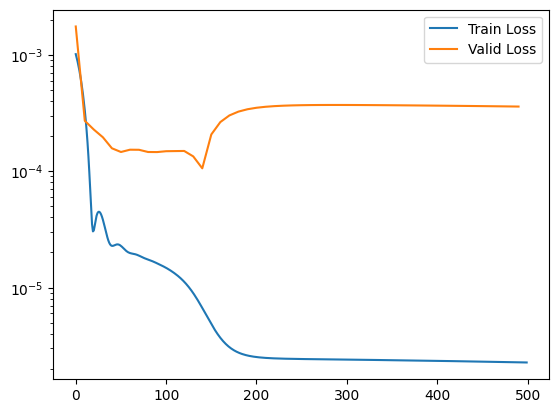

In [4]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

print(len(train_history))

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()